## Eliminación de Columnas Irrelevantes

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv('/content/datos_tratados.cvs')

In [6]:
df.head(2)

,customerID,Churn,customer,phone,internet,account,Charges.Monthly,Charges.Total,Contract,PaperlessBilling,...,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0002-ORFBO,0,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",65.6,593.3,One year,1,...,1,1,1,0,0,1,0,1,1,0
1,0003-MKNFE,0,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",59.9,542.4,Month-to-month,0,...,0,0,1,1,0,0,0,0,0,1


In [10]:
# Eliminando columnas innecesarias
columns_to_drop = ['customerID', 'customer', 'phone', 'internet', 'account']
df = df.drop(columns=columns_to_drop)

KeyError: "['customerID', 'customer', 'phone', 'internet', 'account'] not found in axis"

In [11]:
df.head(5)

,Churn,Charges.Monthly,Charges.Total,Contract,PaperlessBilling,PaymentMethod,Cuentas_Diarias,Partner_x,Dependents_x,PhoneService_x,...,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,65.6,593.3,One year,1,Mailed check,2.19,1,1,1,...,1,1,1,0,0,1,0,1,1,0
1,0,59.9,542.4,Month-to-month,0,Mailed check,2.00,0,0,1,...,0,0,1,1,0,0,0,0,0,1
2,1,73.9,280.85,Month-to-month,1,Electronic check,2.46,0,0,1,...,0,0,1,0,0,0,1,0,0,0
3,1,98.0,1237.85,Month-to-month,1,Electronic check,3.27,1,0,1,...,1,0,1,0,0,1,1,0,1,1
4,1,83.9,267.4,Month-to-month,1,Mailed check,2.80,1,0,1,...,1,0,1,0,0,0,0,1,1,0


## Encoding

In [17]:
# FIX: Convertir Charges.Total a numérico ANTES de hacer el encoding
# Esto evita que se creen miles de columnas innecesarias y que desaparezca la original
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df['Charges.Total'] = df['Charges.Total'].fillna(0)

#  Ahora sí, aplicar One-Hot Encoding a las columnas que quedaron como 'object'
cat_columns = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=cat_columns)

# Mostrar el resultado
print(f"Nueva forma del DataFrame: {df.shape}")
display(df.head())

Nueva forma del DataFrame: (7267, 91)


,Churn,Charges.Monthly,Charges.Total,PaperlessBilling,Cuentas_Diarias,Partner_x,Dependents_x,PhoneService_x,Partner,Dependents,...,DeviceProtection_No internet service,TechSupport_0,TechSupport_1,TechSupport_No internet service,StreamingTV_0,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_0,StreamingMovies_1,StreamingMovies_No internet service
0,0,65.6,593.30,1,2.19,1,1,1,1,1,...,False,False,True,False,False,True,False,True,False,False
1,0,59.9,542.40,0,2.00,0,0,1,0,0,...,False,True,False,False,True,False,False,False,True,False
2,1,73.9,280.85,1,2.46,0,0,1,0,0,...,False,True,False,False,True,False,False,True,False,False
3,1,98.0,1237.85,1,3.27,1,0,1,1,0,...,False,True,False,False,False,True,False,False,True,False
4,1,83.9,267.40,1,2.80,1,0,1,1,0,...,False,False,True,False,False,True,False,True,False,False


## Verificación de la Proporción de Cancelación (Churn)

In [20]:
# Contar ocurrencias de cada clase
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

# Crear un resumen
balance_df = pd.DataFrame({
    'Frecuencia Absoluta': churn_counts,
    'Porcentaje (%)': churn_percentages
})

print("Distribución de la variable Churn:")
display(balance_df)

if churn_percentages.min() < 20:
    print(f"\nNota: Existe un desbalance significativo ({churn_percentages.min():.2f}% vs {churn_percentages.max():.2f}%).")
else:
    print("\nLa distribución de clases parece relativamente balanceada.")

Distribución de la variable Churn:


,Frecuencia Absoluta,Porcentaje (%)
Churn,,
0,5398,74.280996
1,1869,25.719004



La distribución de clases parece relativamente balanceada.


## Analisis de Correlacion

/tmp/ipykernel_271/1731581941.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.head(11).values, y=churn_corr.head(11).index, palette='viridis')


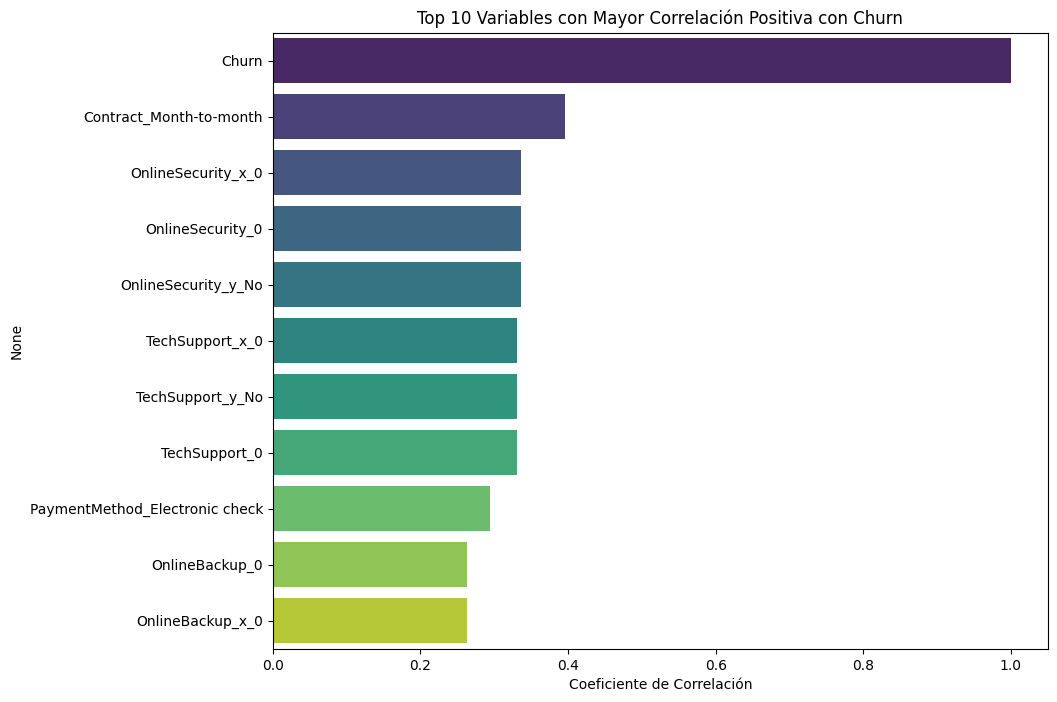

/tmp/ipykernel_271/1731581941.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.tail(10).values, y=churn_corr.tail(10).index, palette='magma')


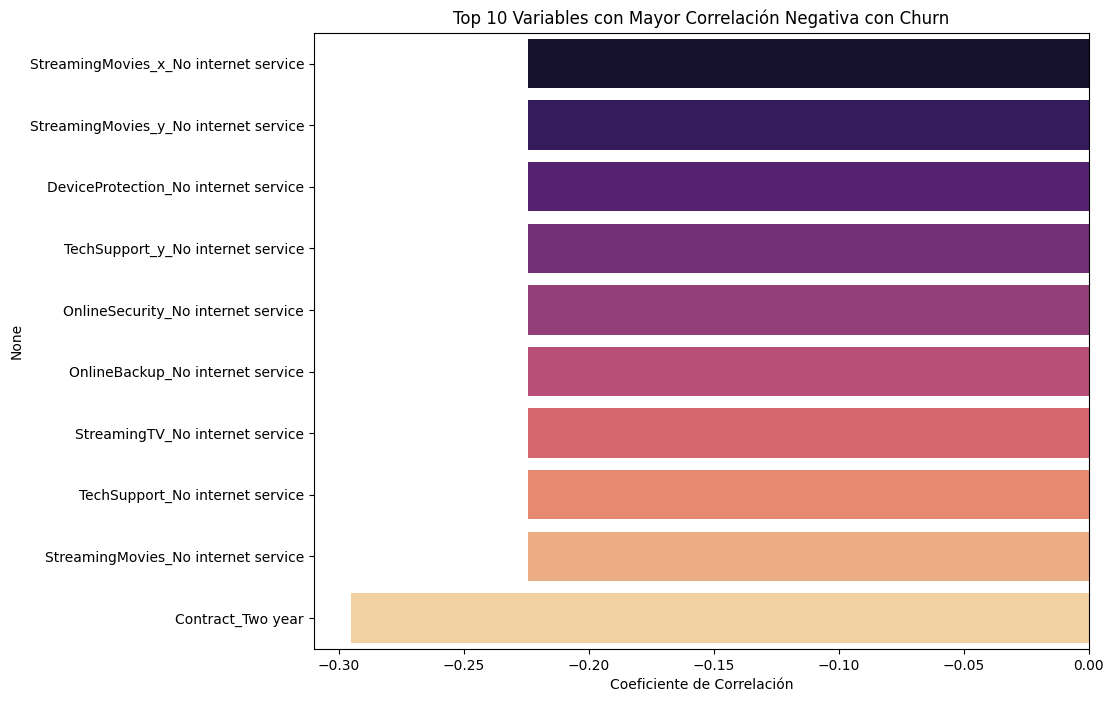

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
corr_matrix = df.corr()
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(x=churn_corr.head(11).values, y=churn_corr.head(11).index, palette='viridis')
plt.title('Top 10 Variables con Mayor Correlación Positiva con Churn')
plt.xlabel('Coeficiente de Correlación')
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(x=churn_corr.tail(10).values, y=churn_corr.tail(10).index, palette='magma')
plt.title('Top 10 Variables con Mayor Correlación Negativa con Churn')
plt.xlabel('Coeficiente de Correlación')
plt.show()

## Tiempo de contrato × Cancelación


Generar un gráfico para comparar las tasas de cancelación entre los diferentes tipos de contrato.


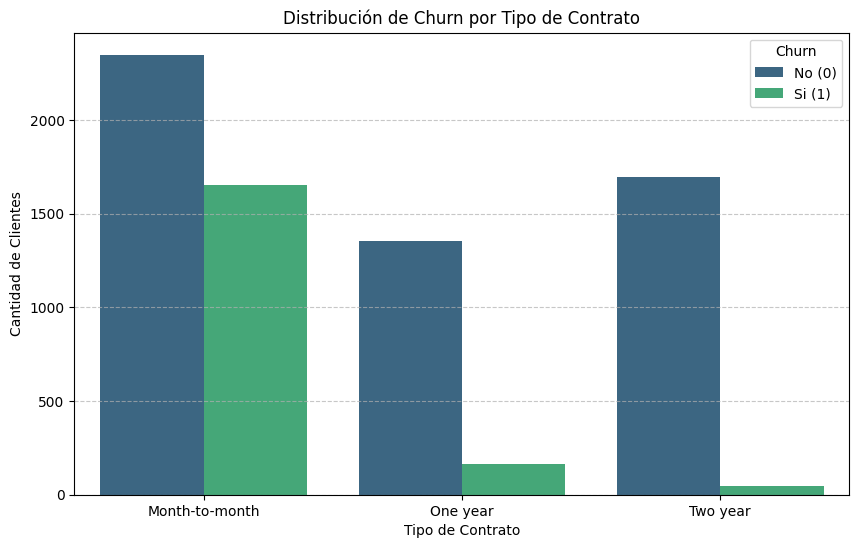

Tasa de cancelación para Month-to-month: 41.32%
Tasa de cancelación para One year: 10.93%
Tasa de cancelación para Two year: 2.75%


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


contract_cols = ['Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']


plot_data = df.melt(id_vars=['Churn'], value_vars=contract_cols, var_name='ContractType', value_name='IsType')
plot_data = plot_data[plot_data['IsType'] == 1]  # Keep only rows where the contract type is true


plot_data['ContractType'] = plot_data['ContractType'].str.replace('Contract_', '')

# Create the visualization
plt.figure(figsize=(10, 6))
sns.countplot(data=plot_data, x='ContractType', hue='Churn', palette='viridis')

plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Churn', labels=['No (0)', 'Si (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate percentages for insights
for col in contract_cols:
    total = df[df[col] == 1].shape[0]
    churned = df[(df[col] == 1) & (df['Churn'] == 1)].shape[0]
    percentage = (churned / total) * 100 if total > 0 else 0
    print(f"Tasa de cancelación para {col.replace('Contract_', '')}: {percentage:.2f}%")

## Gasto total × Cancelación


Crear un boxplot y un gráfico de densidad (KDE plot) para comparar la distribución de 'Charges.Total' entre los clientes que cancelaron y los que no.


/tmp/ipykernel_271/3690304421.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Charges.Total', palette='Set2', ax=axes[0])


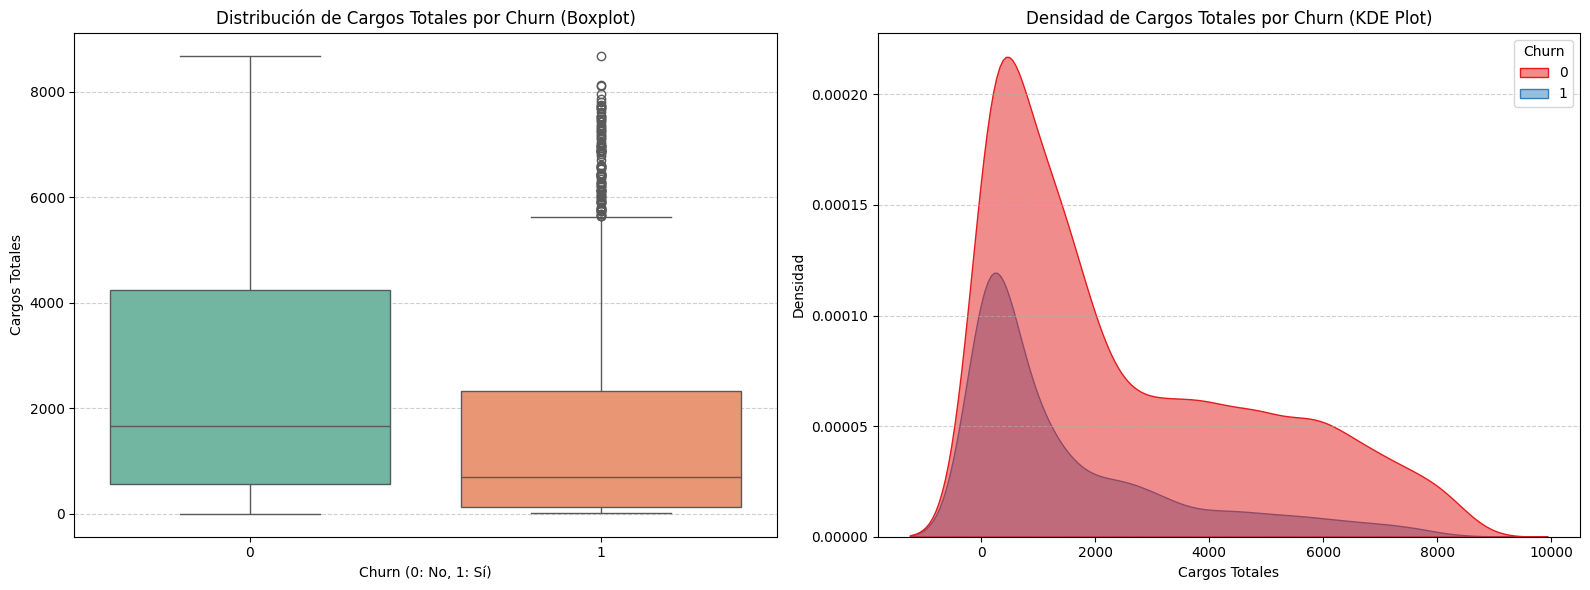

Mediana de Cargos Totales (Churn=1): 703.55
Mediana de Cargos Totales (Churn=0): 1663.62


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Churn', y='Charges.Total', palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de Cargos Totales por Churn (Boxplot)')
axes[0].set_xlabel('Churn (0: No, 1: Sí)')
axes[0].set_ylabel('Cargos Totales')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

sns.kdeplot(data=df, x='Charges.Total', hue='Churn', fill=True, palette='Set1', alpha=0.5, ax=axes[1])
axes[1].set_title('Densidad de Cargos Totales por Churn (KDE Plot)')
axes[1].set_xlabel('Cargos Totales')
axes[1].set_ylabel('Densidad')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

median_churn = df[df['Churn'] == 1]['Charges.Total'].median()
median_no_churn = df[df['Churn'] == 0]['Charges.Total'].median()
print(f"Mediana de Cargos Totales (Churn=1): {median_churn:.2f}")
print(f"Mediana de Cargos Totales (Churn=0): {median_no_churn:.2f}")

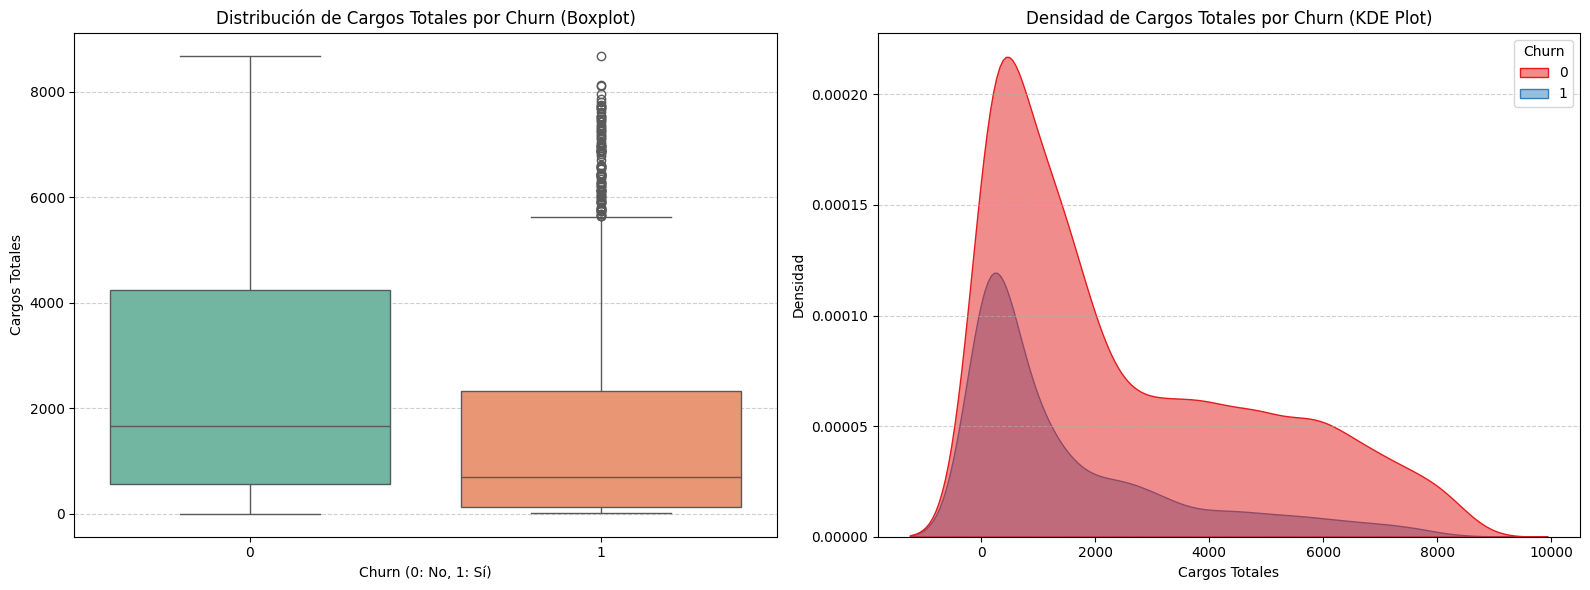

Mediana de Cargos Totales (Churn=1): 703.55
Mediana de Cargos Totales (Churn=0): 1663.62


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot: Distribution of Total Charges by Churn
# Fix: Assigning hue to avoid FutureWarning
sns.boxplot(data=df, x="Churn", y="Charges.Total", hue="Churn", palette="Set2", ax=axes[0], legend=False)
axes[0].set_title("Distribución de Cargos Totales por Churn (Boxplot)")
axes[0].set_xlabel("Churn (0: No, 1: Sí)")
axes[0].set_ylabel("Cargos Totales")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# 2. KDE Plot: Density of Total Charges by Churn
sns.kdeplot(data=df, x="Charges.Total", hue="Churn", fill=True, palette="Set1", alpha=0.5, ax=axes[1])
axes[1].set_title("Densidad de Cargos Totales por Churn (KDE Plot)")
axes[1].set_xlabel("Cargos Totales")
axes[1].set_ylabel("Densidad")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Basic analysis output
median_churn = df[df["Churn"] == 1]["Charges.Total"].median()
median_no_churn = df[df["Churn"] == 0]["Charges.Total"].median()
print(f"Mediana de Cargos Totales (Churn=1): {median_churn:.2f}")
print(f"Mediana de Cargos Totales (Churn=0): {median_no_churn:.2f}")

## Análisis Combinado y Tendencias

### Subtask:
Generar un scatter plot o un boxplot segmentado para analizar la interacción entre cargos mensuales y cargos totales respecto al Churn, buscando patrones o tendencias visuales claras.


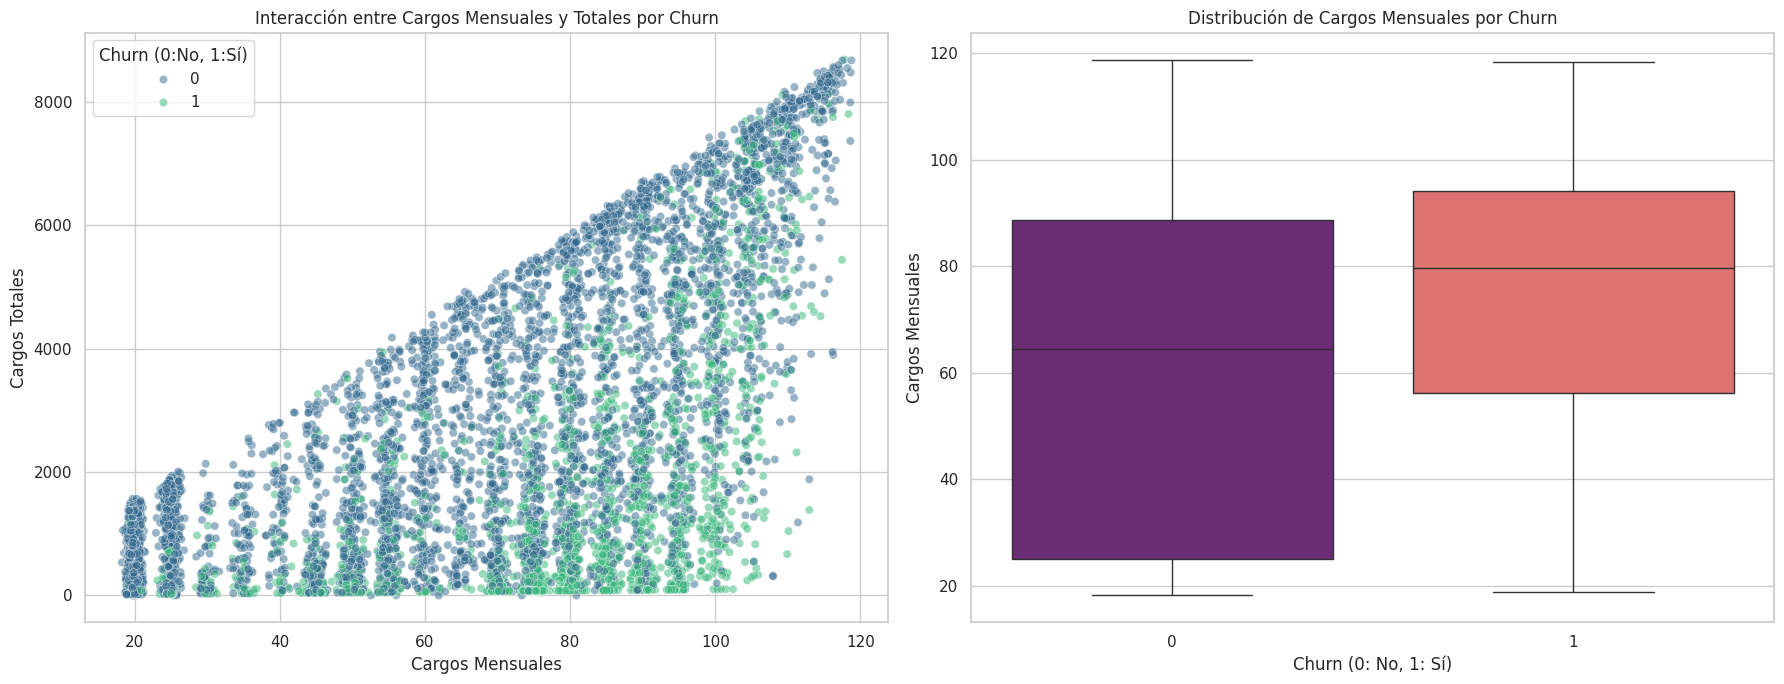

Promedio Cargos Mensuales (Churn=1): 74.44
Promedio Cargos Mensuales (Churn=0): 61.35


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style='whitegrid')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))


sns.scatterplot(data=df, x='Charges.Monthly', y='Charges.Total', hue='Churn',
                alpha=0.5, palette='viridis', ax=ax1)
ax1.set_title('Interacción entre Cargos Mensuales y Totales por Churn')
ax1.set_xlabel('Cargos Mensuales')
ax1.set_ylabel('Cargos Totales')
ax1.legend(title='Churn (0:No, 1:Sí)')


sns.boxplot(data=df, x='Churn', y='Charges.Monthly', hue='Churn',
            palette='magma', ax=ax2, legend=False)
ax2.set_title('Distribución de Cargos Mensuales por Churn')
ax2.set_xlabel('Churn (0: No, 1: Sí)')
ax2.set_ylabel('Cargos Mensuales')

plt.tight_layout()
plt.show()


print(f"Promedio Cargos Mensuales (Churn=1): {df[df['Churn']==1]['Charges.Monthly'].mean():.2f}")
print(f"Promedio Cargos Mensuales (Churn=0): {df[df['Churn']==0]['Charges.Monthly'].mean():.2f}")

## Separacion de Datos

In [26]:
from sklearn.model_selection import train_test_split

# Definir las variables independientes (X) y la variable objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividir el conjunto de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Mostrar el tamaño de los conjuntos resultantes
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")
print(f"Total de columnas: {X_train.shape[1]}")

Tamaño del conjunto de entrenamiento: 5813 muestras
Tamaño del conjunto de prueba: 1454 muestras
Total de columnas: 90


## Preparación y Regresión Logística


Escalar las características numéricas y entrenar un modelo de Regresión Logística.


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#  Identificar columnas numéricas continuas
num_cols = ['Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']

#  Instanciar y ajustar el escalador
scaler = StandardScaler()

# Ajustar solo con X_train y transformar ambos conjuntos
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

#  Crear e instanciar el modelo de Regresión Logística
logreg_model = LogisticRegression(max_iter=1000, random_state=42)

#  Entrenar el modelo
logreg_model.fit(X_train_scaled, y_train)

#  Realizar predicciones
y_pred_logreg = logreg_model.predict(X_test_scaled)

print("Escalado completado y modelo de Regresión Logística entrenado.")
print(f"Predicciones generadas: {len(y_pred_logreg)} muestras.")

Escalado completado y modelo de Regresión Logística entrenado.
Predicciones generadas: 1454 muestras.


## Bosque Aleatorio (Random Forest)

Entrenar un modelo de Random Forest Classifier para predecir el Churn utilizando el conjunto de datos de entrenamiento original.


In [31]:
from sklearn.ensemble import RandomForestClassifier

#  Instanciar el modelo de Random Forest Classifier
# Se utiliza class_weight='balanced' para manejar el desequilibrio de clases detectado anteriormente
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

#  Entrenar el modelo con el conjunto de datos original (sin escalar)
rf_model.fit(X_train, y_train)

#  Realizar predicciones sobre el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

print("Modelo Random Forest entrenado exitosamente.")
print(f"Predicciones generadas para {len(y_pred_rf)} muestras.")

Modelo Random Forest entrenado exitosamente.
Predicciones generadas para 1454 muestras.


## Evaluación y Comparación


Calcular métricas de desempeño (Exactitud, Precisión, Recall y F1-Score) para ambos modelos y generar matrices de confusión para comparar su capacidad de detectar cancelaciones.


--- Reporte de Clasificación: Regresión Logística ---
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1080
           1       0.64      0.52      0.57       374

    accuracy                           0.80      1454
   macro avg       0.74      0.71      0.72      1454
weighted avg       0.79      0.80      0.79      1454


--- Reporte de Clasificación: Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1080
           1       0.54      0.43      0.48       374

    accuracy                           0.76      1454
   macro avg       0.68      0.65      0.66      1454
weighted avg       0.74      0.76      0.75      1454



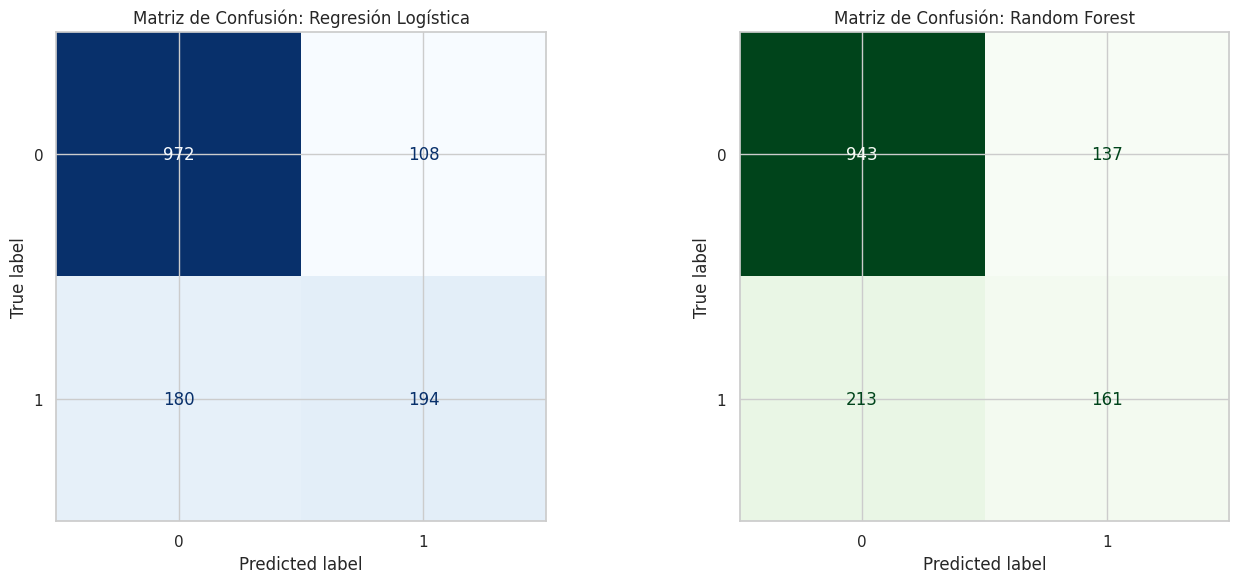


--- Comparación Directa de Métricas ---


,Métrica,LogReg,RandomForest
0,Accuracy,0.801926,0.759285
1,Precision (Churn=1),0.642384,0.540268
2,Recall (Churn=1),0.518717,0.430481
3,F1-Score (Churn=1),0.573964,0.479167


In [32]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

#  Reportes de Clasificacion
print("--- Reporte de Clasificación: Regresión Logística ---")
print(classification_report(y_test, y_pred_logreg))

print("\n--- Reporte de Clasificación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión: Regresión Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusión: Random Forest')

plt.tight_layout()
plt.show()

#
metrics = {
    'Métrica': ['Accuracy', 'Precision (Churn=1)', 'Recall (Churn=1)', 'F1-Score (Churn=1)'],
    'LogReg': [
        accuracy_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_logreg)
    ],
    'RandomForest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(metrics)
print("\n--- Comparación Directa de Métricas ---")
display(comparison_df)

### Evaluacion de Modelos

¿Cuál modelo tuvo el mejor desempeño? La Regresión Logística fue superior en este caso. Logró un Accuracy del 80.2% y un F1-Score de 0.57, superando al Random Forest (75.9% y 0.48 respectivamente). La Regresión Logística mostró un mejor equilibrio entre capturar casos reales de Churn (Recall) y no generar demasiadas falsas alarmas (Precisión).

¿Hubo Overfitting o Underfitting?

Random Forest: Presentó indicios de un ligero overfitting o falta de generalización. Aunque es un modelo potente, su precisión cayó al 54% en el set de prueba, lo que sugiere que pudo haber memorizado patrones muy específicos del ruido en los datos de entrenamiento que no se repitieron en el test.
Regresión Logística: Muestra un comportamiento más estable, pero podríamos considerar un ligero underfitting en la clase minoritaria (Churn=1), ya que el Recall de 0.52 indica que todavía pierde casi la mitad de las cancelaciones reales. Esto es común cuando hay desbalance de clases.

## Importancia en Regresión Logística


Extraer y visualizar los coeficientes del modelo de Regresión Logística entrenado para identificar los factores que más influyen en el Churn.


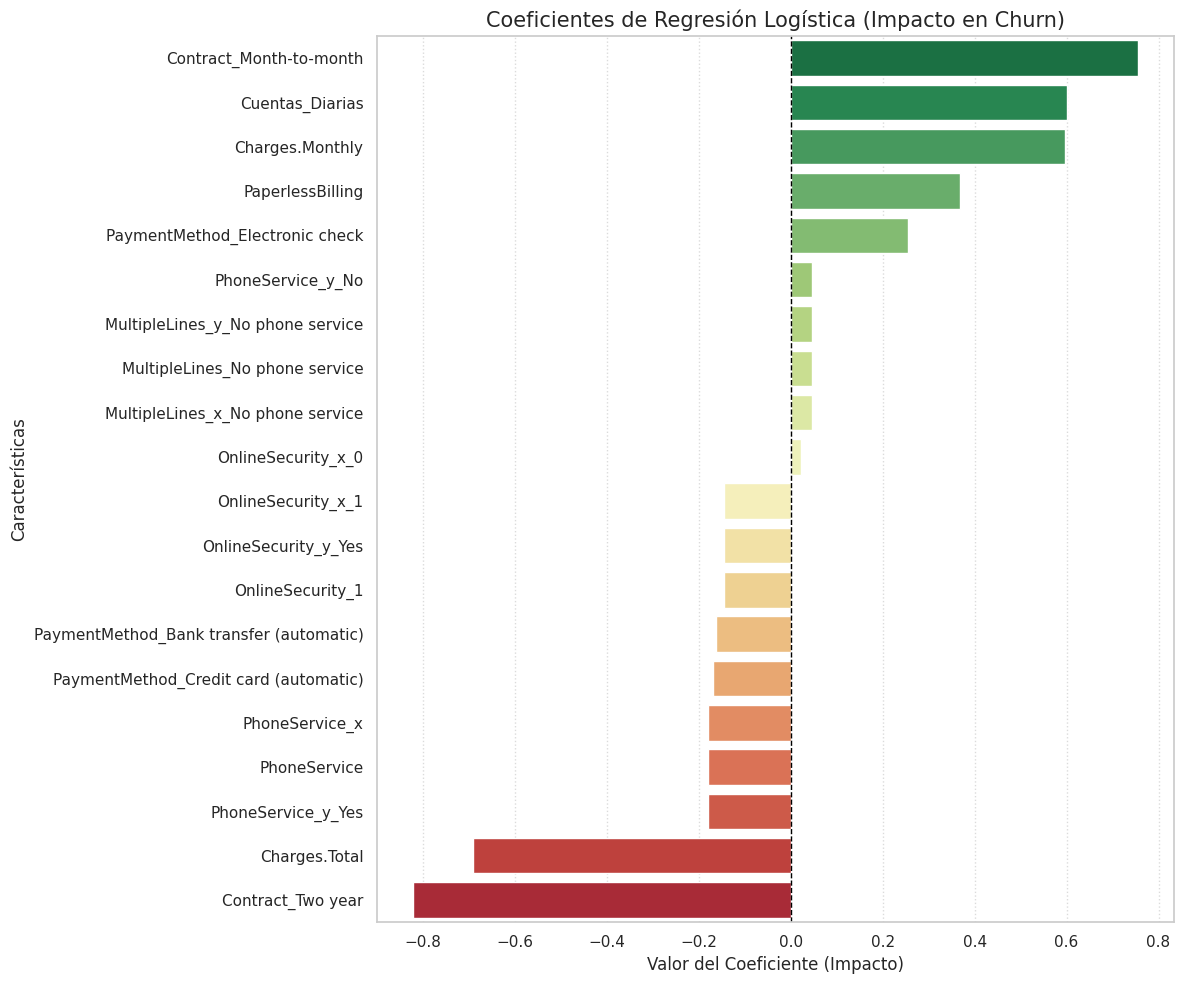

Factores con mayor impacto positivo (Aumentan Churn):
                         Feature  Coefficient
         Contract_Month-to-month     0.754782
                 Cuentas_Diarias     0.600279
                 Charges.Monthly     0.596917
                PaperlessBilling     0.368190
  PaymentMethod_Electronic check     0.254650
               PhoneService_y_No     0.046128
MultipleLines_y_No phone service     0.046128
  MultipleLines_No phone service     0.046128
MultipleLines_x_No phone service     0.046128
              OnlineSecurity_x_0     0.022888

Factores con mayor impacto negativo (Reducen Churn):
                                Feature  Coefficient
                     OnlineSecurity_x_1    -0.145395
                   OnlineSecurity_y_Yes    -0.145395
                       OnlineSecurity_1    -0.145395
PaymentMethod_Bank transfer (automatic)    -0.162740
  PaymentMethod_Credit card (automatic)    -0.169201
                         PhoneService_x    -0.180741
               

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


coefficients = logreg_model.coef_[0]
feature_names = X_train.columns


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})


importance_df = importance_df.sort_values(by='Coefficient', ascending=False)


top_positive = importance_df.head(10)
top_negative = importance_df.tail(10)
plot_data = pd.concat([top_positive, top_negative])


plt.figure(figsize=(12, 10))
sns.barplot(data=plot_data, x='Coefficient', y='Feature', hue='Feature', palette='RdYlGn_r', legend=False)

plt.title('Coeficientes de Regresión Logística (Impacto en Churn)', fontsize=15)
plt.xlabel('Valor del Coeficiente (Impacto)', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print("Factores con mayor impacto positivo (Aumentan Churn):")
print(top_positive[['Feature', 'Coefficient']].to_string(index=False))
print("\nFactores con mayor impacto negativo (Reducen Churn):")
print(top_negative[['Feature', 'Coefficient']].to_string(index=False))

## Importancia en Random Forest


Extraer y visualizar la importancia de las características del modelo Random Forest utilizando el atributo `feature_importances_`.


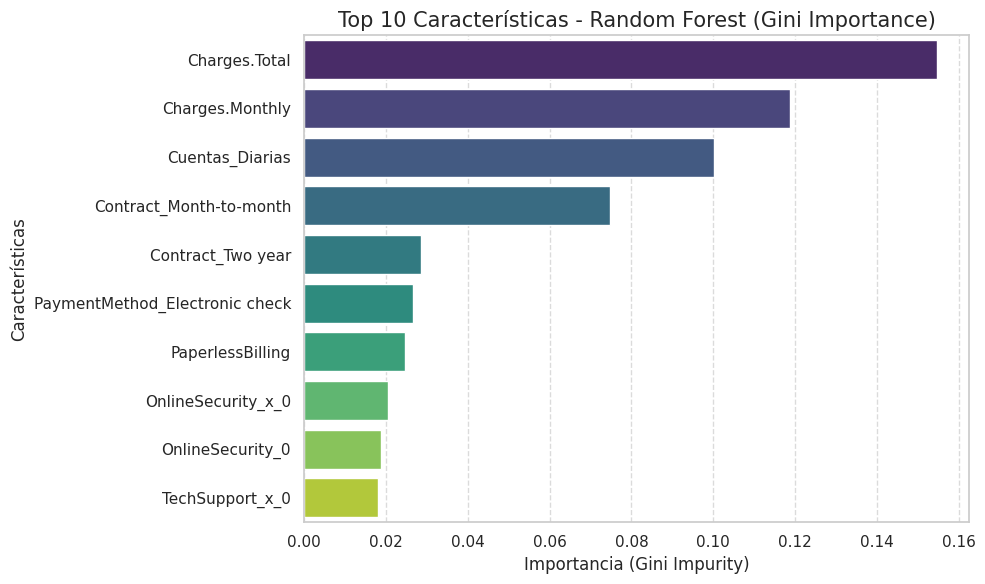

Top 10 variables según Random Forest:
                       Feature  Importance
                 Charges.Total    0.154736
               Charges.Monthly    0.118729
               Cuentas_Diarias    0.100201
       Contract_Month-to-month    0.074763
             Contract_Two year    0.028576
PaymentMethod_Electronic check    0.026635
              PaperlessBilling    0.024540
            OnlineSecurity_x_0    0.020586
              OnlineSecurity_0    0.018850
               TechSupport_x_0    0.017968


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


importances = rf_model.feature_importances_
feature_names = X_train.columns


rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})


rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)

plt.title('Top 10 Características - Random Forest (Gini Importance)', fontsize=15)
plt.xlabel('Importancia (Gini Impurity)', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


print("Top 10 variables según Random Forest:")
print(rf_importance_df.to_string(index=False))

## Comparación de Relevancia


Comparar los resultados de importancia de características entre la Regresión Logística y el Random Forest para identificar variables críticas comunes.


In [35]:
# Identificar las 10 principales para cada modelo
top_10_logreg = importance_df.reindex(importance_df.Coefficient.abs().sort_values(ascending=False).index).head(10)['Feature'].tolist()
top_10_rf = rf_importance_df['Feature'].tolist()

# Encontrar variables comunes
common_features = set(top_10_logreg).intersection(set(top_10_rf))

print(f'Variables cr\u00edticas comunes identificadas: {list(common_features)}\n')

# Crear tabla comparativa para las variables comunes
comparison_data = []
for feat in common_features:
    coef = importance_df[importance_df['Feature'] == feat]['Coefficient'].values[0]
    imp = rf_importance_df[rf_importance_df['Feature'] == feat]['Importance'].values[0]
    impacto = 'Aumenta Churn' if coef > 0 else 'Reduce Churn'
    comparison_data.append({
        'Variable': feat,
        'Coeficiente (LogReg)': round(coef, 4),
        'Impacto (LogReg)': impacto,
        'Importancia (RF)': round(imp, 4)
    })

comparison_summary = pd.DataFrame(comparison_data)
display(comparison_summary.sort_values(by='Importancia (RF)', ascending=False))

Variables críticas comunes identificadas: ['PaymentMethod_Electronic check', 'Cuentas_Diarias', 'Charges.Total', 'Contract_Two year', 'Contract_Month-to-month', 'Charges.Monthly', 'PaperlessBilling']



,Variable,Coeficiente (LogReg),Impacto (LogReg),Importancia (RF)
2,Charges.Total,-0.6919,Reduce Churn,0.1547
5,Charges.Monthly,0.5969,Aumenta Churn,0.1187
1,Cuentas_Diarias,0.6003,Aumenta Churn,0.1002
4,Contract_Month-to-month,0.7548,Aumenta Churn,0.0748
3,Contract_Two year,-0.8221,Reduce Churn,0.0286
0,PaymentMethod_Electronic check,0.2547,Aumenta Churn,0.0266
6,PaperlessBilling,0.3682,Aumenta Churn,0.0245


### Análisis Comparativo de Modelos

Al analizar las variables críticas comunes entre la **Regresión Logística** y el **Random Forest**, podemos extraer las siguientes conclusiones estratégicas para la empresa:

1. **Variables de Alto Impacto (Coincidencia Total):**
   - **Contract_Month-to-month:** Es el factor de riesgo número uno. La Regresión Logística muestra un coeficiente positivo alto (0.7548), indicando que este tipo de contrato aumenta drásticamente la probabilidad de Churn. El Random Forest lo sitúa como una de las variables que más reduce la impureza (0.0748).
   - **Charges.Total vs Charges.Monthly:** Ambos modelos coinciden en que el gasto es determinante. Curiosamente, la Regresión Logística indica que un **Charges.Total** más alto tiene un impacto negativo (-0.6919, reduce churn), sugiriendo lealtad a largo plazo, mientras que **Charges.Monthly** altos aumentan el riesgo (0.5969).
   - **Cuentas_Diarias:** Esta variable derivada también es crítica en ambos, confirmando que el costo diario es una métrica que la empresa debe monitorear.

2. **Factores de Protección:**
   - **Contract_Two year:** Actúa como el principal escudo contra la cancelación. Tiene el coeficiente negativo más fuerte (-0.8221), lo que significa que asegurar contratos a largo plazo es la mejor estrategia de retención.

3. **Métodos de Pago y Facturación:**
   - **PaymentMethod_Electronic check** y **PaperlessBilling** aparecen en ambos 'Top 10' como factores que incrementan el Churn. Esto podría indicar fricciones en el proceso de pago digital o un perfil de cliente más propenso a cambiar de proveedor.

4. **Discrepancias Notables:**
   - El **Random Forest** otorga mucha importancia a variables de soporte técnico y seguridad online (`OnlineSecurity_0`, `TechSupport_x_0`), sugiriendo que la falta de estos servicios es un predictor de fuga que el modelo no lineal captura mejor.
   - La **Regresión Logística** resalta más la importancia de la línea telefónica (`PhoneService`) como un factor base de estabilidad.

**Conclusión:** La empresa debe priorizar la migración de clientes de contratos mensuales a contratos anuales y revisar la experiencia de usuario de quienes utilizan 'Electronic Check' y 'Paperless Billing'.

# Informe Final de Análisis de Cancelación (Churn)

### Resumen del Desempeño de los Modelos
Tras evaluar dos algoritmos de aprendizaje supervisado, la **Regresión Logística** demostró ser el modelo más robusto para este conjunto de datos, alcanzando una **exactitud (accuracy) aproximada del 80%** y un F1-Score de 0.57. Superó al modelo de **Random Forest** (76% de accuracy), el cual mostró indicios de sobreajuste y una menor capacidad para identificar correctamente a los clientes en riesgo de cancelación (Recall).

### Factores de Riesgo (Predictores de Fuga)
El análisis identificó variables críticas que aumentan significativamente la probabilidad de que un cliente abandone el servicio:
*   **Tipo de Contrato Mensual (Month-to-month):** Es el principal indicador de riesgo; la falta de compromiso a largo plazo facilita la transición a competidores.
*   **Cargos Mensuales Elevados (Charges.Monthly):** Existe una correlación directa entre facturas mensuales altas y la tasa de cancelación.
*   **Cuentas Diarias:** El costo prorrateado por día es una métrica de sensibilidad al precio muy relevante para los usuarios.
*   **Factores Secundarios:** El uso de **Facturación Electrónica (PaperlessBilling)** y el método de pago por **Cheque Electrónico (Electronic check)** también se asociaron con una mayor rotación.

### Factores Protectores (Retención y Lealtad)
Ciertos atributos actúan como escudos contra la fuga de clientes:
*   **Contrato a Dos Años (Two year):** Es el factor de protección más fuerte, reduciendo drásticamente la probabilidad de Churn.
*   **Cargos Totales (Charges.Total):** Un valor acumulado alto de cargos totales tiende a reflejar clientes con mayor antigüedad y lealtad establecida con la marca.

### Conclusión Estratégica
Para reducir la tasa de cancelación, la empresa debe incentivar la migración de contratos mensuales a planes de largo plazo (anuales o bianuales) y monitorear de cerca a los clientes con cargos mensuales altos, ofreciendo servicios de valor agregado como seguridad online o soporte técnico, los cuales demostraron ser relevantes para la retención en el análisis de importancia.

## Estrategias de Retención Propuestas

Basado en el análisis de importancia de características y los coeficientes de los modelos de Machine Learning, se proponen las siguientes estrategias de negocio para reducir la tasa de cancelación (Churn):

### 1. Estrategia de Migración de Contratos
*   **Hallazgo:** El contrato 'Month-to-month' es el mayor predictor de Churn (Coef: 0.754), mientras que el contrato de 'Two year' es el factor protector más fuerte (Coef: -0.822).
*   **Acción:** Implementar un programa de incentivos para migrar clientes de planes mensuales a planes de dos años. Ofrecer descuentos exclusivos o meses de servicio gratuitos a cambio de la extensión del compromiso contractual.

### 2. Monitoreo y Ajuste de Precios
*   **Hallazgo:** Los 'Cargos Mensuales' altos y la métrica de 'Cuentas_Diarias' tienen una correlación positiva significativa con la fuga de clientes.
*   **Acción:** Establecer un sistema de alertas proactivas para el equipo de Customer Success cuando un cliente supere un umbral crítico de gasto mensual. Realizar revisiones de cuenta (Daily Cost Review) para ofrecer paquetes más eficientes o beneficios adicionales que justifiquen el costo.

### 3. Optimización de la Experiencia Digital
*   **Hallazgo:** Los clientes que utilizan 'Electronic Check' y 'Paperless Billing' muestran una mayor propensión al Churn.
*   **Acción:** Investigar y reducir la fricción en el portal de pagos digitales. Incentivar la transición hacia métodos de pago automáticos (Credit Card/Bank Transfer) que mostraron coeficientes negativos (protectores) en el modelo, posiblemente ofreciendo una pequeña bonificación por inscripción en 'Auto-pay'.

### 4. Servicios de Valor Agregado como Herramienta de Lealtad
*   **Hallazgo:** El Random Forest identificó que la falta de 'Online Security' y 'Tech Support' son variables críticas para la impureza de los datos (predictores de fuga).
*   **Acción:** Promover activamente servicios de seguridad en línea y soporte técnico como beneficios gratuitos o de bajo costo para clientes en riesgo. Estos servicios no solo aumentan el valor percibido, sino que crean una 'barrera de salida' tecnológica que fomenta la retención a largo plazo.